# Two nonlinear sensors → inverse sensor model as a LUT → fusion

Goals:
1. Simulate two sensors with nonlinear response curves, different bias, and Gaussian noise
2. Visualize both response curves
3. Build a separate *inverse* sensor model (ISM) as a look-up table (LUT) from samples for each sensor
4. Use the LUT-ISMs to perform sensor fusion (weighted mean)

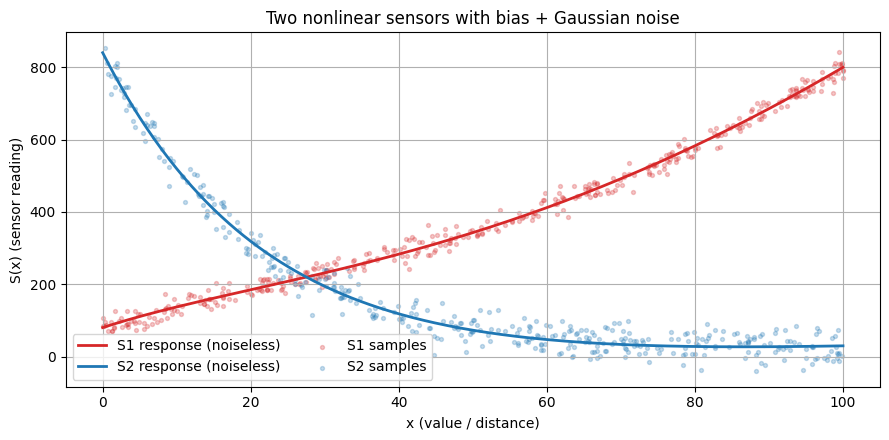

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def s1_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically increasing response curve."""
    x = np.asarray(x)
    return 120.0 * (1.0 - np.exp(-x / 18.0)) + 0.06 * x**2


def s2_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically decreasing response curve."""
    x = np.asarray(x)
    return 900.0 * np.exp(-x / 22.0) + 0.8 * x


class NonlinearSensor:
    def __init__(self, name: str, forward_fn, bias: float, sigma: float):
        self.name = name
        self.forward_fn = forward_fn
        self.bias = float(bias)
        self.sigma = float(sigma)

    def sample(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x)
        noise = rng.normal(loc=0.0, scale=self.sigma, size=x.shape)
        return self.forward_fn(x) + self.bias + noise

    def calibration_samples(self, n: int, x_min: float, x_max: float):
        x = rng.uniform(x_min, x_max, size=n)
        s = self.sample(x)
        return x, s


# 1) Define sensors (different bias + noise)
x_min, x_max = 0.0, 100.0
sensor1 = NonlinearSensor(name="S1", forward_fn=s1_forward, bias=+80.0, sigma=18.0)
sensor2 = NonlinearSensor(name="S2", forward_fn=s2_forward, bias=-60.0, sigma=30.0)

# 2) Visualize response curves (noiseless curve + noisy samples)
x_grid = np.linspace(x_min, x_max, 400)

n_calib = 4000
x1_cal, s1_cal = sensor1.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)
x2_cal, s2_cal = sensor2.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)

plt.figure(figsize=(9, 4.5))
plt.plot(x_grid, s1_forward(x_grid) + sensor1.bias, color="tab:red", lw=2, label="S1 response (noiseless)")
plt.plot(x_grid, s2_forward(x_grid) + sensor2.bias, color="tab:blue", lw=2, label="S2 response (noiseless)")

plt.scatter(x1_cal[::10], s1_cal[::10], s=8, alpha=0.25, color="tab:red", label="S1 samples")
plt.scatter(x2_cal[::10], s2_cal[::10], s=8, alpha=0.25, color="tab:blue", label="S2 samples")

plt.xlabel("x (value / distance)")
plt.ylabel("S(x) (sensor reading)")
plt.title("Two nonlinear sensors with bias + Gaussian noise")
plt.grid(True)
plt.legend(ncols=2)
plt.tight_layout()
plt.show()

RMSE(ISMs, LUT): S1 ≈ 3.95 x-Einheiten, S2 ≈ 15.78 x-Einheiten


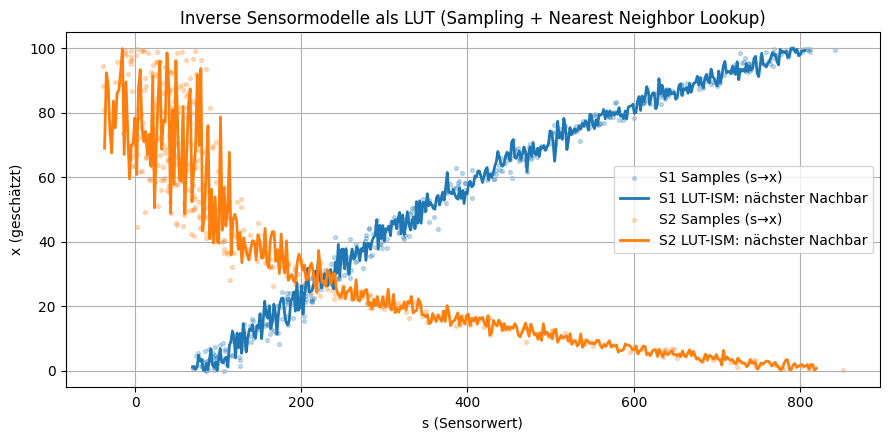

In [ ]:
# 3) Inverse Sensor Model (ISM) as a Look-Up Table (LUT)
#    - Store calibration samples (x_i, s_i)
#    - For inversion s -> x: find the LUT entry with the closest sensor reading.


class LUTInverseModel:
    def __init__(self, s_samples: np.ndarray, x_samples: np.ndarray):
        s = np.asarray(s_samples).astype(float)
        x = np.asarray(x_samples).astype(float)

        order = np.argsort(s)
        self.s = s[order]
        self.x = x[order]

    def predict(self, s_query: np.ndarray) -> np.ndarray:
        sq = np.asarray(s_query).astype(float)

        # For each sq: find the insertion position in sorted s,
        # then choose the closer of (idx-1, idx).
        idx = np.searchsorted(self.s, sq, side="left")
        idx0 = np.clip(idx - 1, 0, len(self.s) - 1)
        idx1 = np.clip(idx, 0, len(self.s) - 1)

        d0 = np.abs(sq - self.s[idx0])
        d1 = np.abs(sq - self.s[idx1])
        choose1 = d1 < d0

        out = np.where(choose1, self.x[idx1], self.x[idx0])
        return out


def train_lut_ism(x: np.ndarray, s: np.ndarray, train_frac: float = 0.75):
    """Train/validation split of samples and an RMSE estimate for the LUT-ISM."""
    x = np.asarray(x)
    s = np.asarray(s)

    n = len(x)
    perm = rng.permutation(n)
    n_tr = int(train_frac * n)
    tr = perm[:n_tr]
    te = perm[n_tr:]

    ism = LUTInverseModel(s_samples=s[tr], x_samples=x[tr])
    x_hat = ism.predict(s[te])
    rmse = float(np.sqrt(np.mean((x_hat - x[te]) ** 2)))
    return ism, rmse


ism1, rmse1 = train_lut_ism(x1_cal, s1_cal, train_frac=0.75)
ism2, rmse2 = train_lut_ism(x2_cal, s2_cal, train_frac=0.75)

print(f"RMSE(ISMs, LUT): S1 ≈ {rmse1:.2f} x-units, S2 ≈ {rmse2:.2f} x-units")

# Visualization: inverse curve x(s) (discrete/step-like due to nearest-neighbor LUT)

def plot_inverse(sensor_name: str, s_samples: np.ndarray, x_samples: np.ndarray, ism: LUTInverseModel):
    s_lo, s_hi = np.percentile(s_samples, [0.5, 99.5])
    s_grid = np.linspace(s_lo, s_hi, 400)
    x_pred = ism.predict(s_grid)

    plt.scatter(s_samples[::10], x_samples[::10], s=8, alpha=0.25, label=f"{sensor_name} samples (s→x)")
    plt.plot(s_grid, x_pred, lw=2, label=f"{sensor_name} LUT-ISM: nearest neighbor")


plt.figure(figsize=(9, 4.5))
plot_inverse("S1", s1_cal, x1_cal, ism1)
plot_inverse("S2", s2_cal, x2_cal, ism2)
plt.xlabel("s (sensor reading)")
plt.ylabel("x (estimated)")
plt.title("Inverse sensor models as a LUT (sampling + nearest-neighbor lookup)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

RMSE (Test):
  nur S1:   3.88
  nur S2:   15.64
  fusion:   3.79


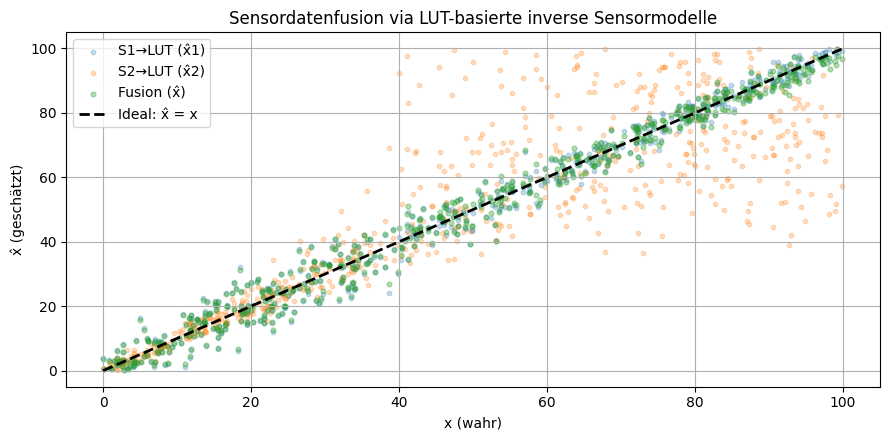

In [ ]:
# 4) Fusion: LUT-ISM provides x̂1, x̂2; fuse via a weighted mean
#    We use constant weights derived from LUT RMSE (simple and easy to follow).

n_test = 600
x_true = rng.uniform(x_min, x_max, size=n_test)

s1_meas = sensor1.sample(x_true)
s2_meas = sensor2.sample(x_true)

x1_hat = ism1.predict(s1_meas)
x2_hat = ism2.predict(s2_meas)

w1 = 1.0 / (rmse1**2 + 1e-12)
w2 = 1.0 / (rmse2**2 + 1e-12)
x_fused = (w1 * x1_hat + w2 * x2_hat) / (w1 + w2)

err1 = x1_hat - x_true
err2 = x2_hat - x_true
errf = x_fused - x_true

print(
    "RMSE (test):\n"
    f"  only S1:  {np.sqrt(np.mean(err1**2)):.2f}\n"
    f"  only S2:  {np.sqrt(np.mean(err2**2)):.2f}\n"
    f"  fusion:   {np.sqrt(np.mean(errf**2)):.2f}"
)

plt.figure(figsize=(9, 4.5))
plt.scatter(x_true, x1_hat, s=10, alpha=0.25, label="S1→LUT (x̂1)")
plt.scatter(x_true, x2_hat, s=10, alpha=0.25, label="S2→LUT (x̂2)")
plt.scatter(x_true, x_fused, s=12, alpha=0.35, label="Fusion (x̂)")

plt.plot([x_min, x_max], [x_min, x_max], "k--", lw=2, label="Ideal: x̂ = x")
plt.xlabel("x (true)")
plt.ylabel("x̂ (estimated)")
plt.title("Sensor fusion via LUT-based inverse sensor models")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Note on the idea (ISM as a LUT)

- Forward model: $x \rightarrow S(x)$ (response curve + bias + noise)
- Collect calibration samples: pairs $(x_i, s_i)$
- LUT-ISM: given a measurement $s$ → find the *closest* sensor reading $s_i$ in the LUT → return the associated $x_i$
- Fusion: combine $\hat{x}_1$ and $\hat{x}_2$ (here: constant weights based on RMSE)

In [ ]:
# Small single example
x0 = 10.0
s1_0 = float(sensor1.sample(np.array([x0]))[0])
s2_0 = float(sensor2.sample(np.array([x0]))[0])

x1_0 = float(ism1.predict(np.array([s1_0]))[0])
x2_0 = float(ism2.predict(np.array([s2_0]))[0])
x_f0 = float((w1 * x1_0 + w2 * x2_0) / (w1 + w2))

print(f"x_true={x0:.2f}")
print(f"S1 measures s={s1_0:.2f}  → LUT: x̂1={x1_0:.2f}")
print(f"S2 measures s={s2_0:.2f}  → LUT: x̂2={x2_0:.2f}")
print(f"Fusion (weighted): x̂={x_f0:.2f}")

x_true=10.00
S1 misst s=126.88  → LUT: x̂1=9.46
S2 misst s=510.46  → LUT: x̂2=9.98
Fusion (gewichtet): x̂=9.49


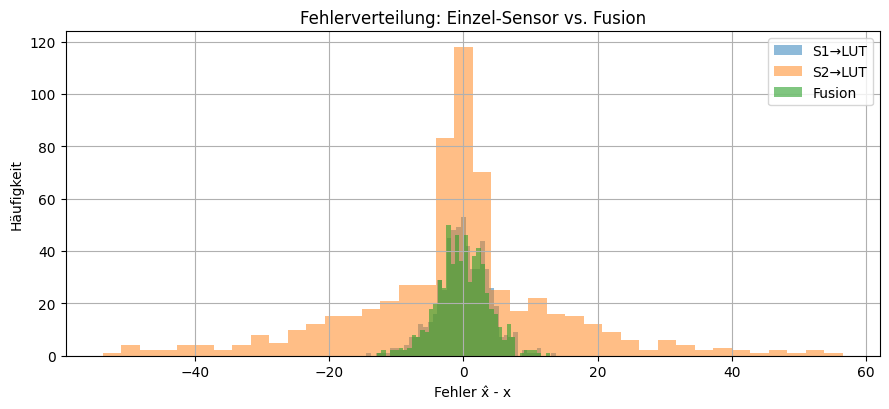

In [ ]:
# (Optional) Error distributions as a histogram
plt.figure(figsize=(9, 4.2))
plt.hist(err1, bins=40, alpha=0.5, label="S1→LUT")
plt.hist(err2, bins=40, alpha=0.5, label="S2→LUT")
plt.hist(errf, bins=40, alpha=0.6, label="Fusion")
plt.xlabel("Error x̂ - x")
plt.ylabel("Count")
plt.title("Error distribution: single sensor vs fusion")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()